##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

Using device: cpu


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 2632.40it/s]


DINOv2 model loaded successfully.
Dataset loaded successfully.
Number of images: 3680

Selected images: 20
Cats selected: 10
Dogs selected: 10
Selected labels: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]

CLS token feature shape: (20, 384)
Each CLS token dimension: 384

Raw KMeans cluster labels:
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]

Mapped predictions:
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]

Final Results
Accuracy: 100.00%

Confusion Matrix:
[[10  0]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

         Cat       1.00      1.00      1.00        10
         Dog       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



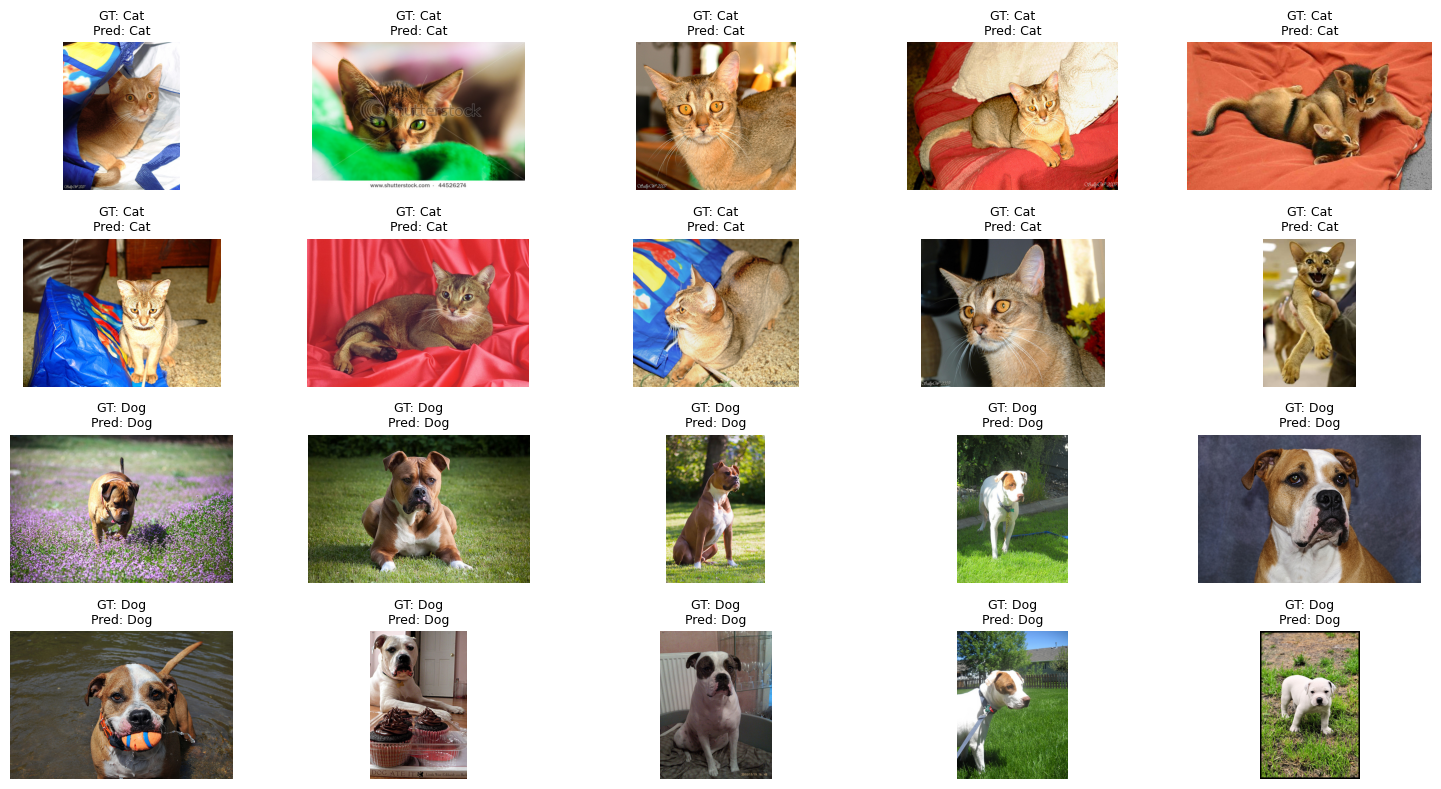

In [4]:
# Provide your solution here
# ============================================================
# Exercise 1: KMeans Clustering using DINOv2 CLS Tokens
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import OxfordIIITPet
from transformers import AutoImageProcessor, AutoModel
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ============================================================
# 1. Load DINOv2 model
# ============================================================

MODEL_ID = "facebook/dinov2-small"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()

print("DINOv2 model loaded successfully.")


# ============================================================
# 2. Load Oxford-IIIT Pet dataset with binary labels
# binary-category means:
# 0 = Cat
# 1 = Dog
# ============================================================

dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="binary-category",
    download=True
)

print("Dataset loaded successfully.")
print("Number of images:", len(dataset))


# ============================================================
# 3. Select 10 cats and 10 dogs
# ============================================================

cat_images = []
dog_images = []

for img, label in dataset:
    # In binary-category:
    # 0 = Cat
    # 1 = Dog

    if label == 0 and len(cat_images) < 10:
        cat_images.append(img)

    elif label == 1 and len(dog_images) < 10:
        dog_images.append(img)

    if len(cat_images) == 10 and len(dog_images) == 10:
        break


selected_images = cat_images + dog_images
selected_labels = np.array([0] * len(cat_images) + [1] * len(dog_images))

print("\nSelected images:", len(selected_images))
print("Cats selected:", len(cat_images))
print("Dogs selected:", len(dog_images))
print("Selected labels:", selected_labels)


# Safety check
assert len(cat_images) == 10, "Error: Less than 10 cats selected."
assert len(dog_images) == 10, "Error: Less than 10 dogs selected."
assert len(selected_images) == 20, "Error: Total selected images should be 20."


# ============================================================
# 4. Extract 384-dimensional CLS tokens
# ============================================================

def extract_cls_token(image):
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # CLS token is the first token
    cls_token = outputs.last_hidden_state[:, 0, :]

    return cls_token.squeeze().cpu().numpy()


features = []

for img in selected_images:
    cls_vector = extract_cls_token(img)
    features.append(cls_vector)

features = np.array(features)

print("\nCLS token feature shape:", features.shape)
print("Each CLS token dimension:", features.shape[1])

assert features.shape == (20, 384), "Error: Features should have shape (20, 384)."


# ============================================================
# 5. Apply KMeans Clustering
# ============================================================

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features)

print("\nRaw KMeans cluster labels:")
print(cluster_labels)


# ============================================================
# 6. Map KMeans clusters to Cat/Dog labels
# KMeans labels are arbitrary, so we use majority vote
# ============================================================

mapped_predictions = np.zeros_like(cluster_labels)

for cluster_id in [0, 1]:
    indices = np.where(cluster_labels == cluster_id)[0]
    true_labels_in_cluster = selected_labels[indices]

    majority_label = np.bincount(true_labels_in_cluster).argmax()
    mapped_predictions[indices] = majority_label

print("\nMapped predictions:")
print(mapped_predictions)


# ============================================================
# 7. Compare predicted clusters with ground-truth labels
# ============================================================

accuracy = accuracy_score(selected_labels, mapped_predictions)
cm = confusion_matrix(selected_labels, mapped_predictions, labels=[0, 1])

print("\nFinal Results")
print("=" * 40)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    selected_labels,
    mapped_predictions,
    labels=[0, 1],
    target_names=["Cat", "Dog"],
    zero_division=0
))


# ============================================================
# 8. Visualize Results
# ============================================================

plt.figure(figsize=(15, 8))

for i, img in enumerate(selected_images):
    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")

    gt = "Cat" if selected_labels[i] == 0 else "Dog"
    pred = "Cat" if mapped_predictions[i] == 0 else "Dog"

    plt.title(f"GT: {gt}\nPred: {pred}", fontsize=9)

plt.tight_layout()
plt.show()

The KMeans algorithm was able to cluster all selected images correctly. After extracting the 384-dimensional CLS tokens from 20 Oxford-IIIT Pet images, including 10 cats and 10 dogs, KMeans grouped the feature vectors into two clusters based on their visual similarity. The predicted clusters matched the ground-truth labels for all images, achieving 100% accuracy. The confusion matrix showed that all 10 cat images were assigned to the cat cluster and all 10 dog images were assigned to the dog cluster. This indicates that the DINOv2 CLS tokens provided strong visual representations that were effective for separating cats and dogs in this selected sample.

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

Using device: cpu


Loading weights: 100%|██████████| 225/225 [00:00<00:00, 1141.07it/s]


DINOv2 classification model loaded successfully.
Model ID: facebook/dinov2-small-imagenet1k-1-layer


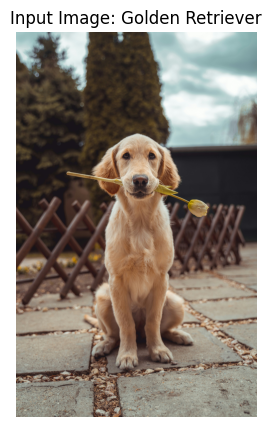


Top-5 Predictions:
1. golden retriever --> 92.02%
2. Labrador retriever --> 3.30%
3. tennis ball --> 1.31%
4. Brittany spaniel --> 1.18%
5. English setter --> 0.45%

Final Prediction
Predicted class: golden retriever
Confidence: 92.02%


In [7]:
# Provide your solution here
# ============================================================
# Exercise 2: Image Classification with DINOv2
# ============================================================

import torch
import requests
import matplotlib.pyplot as plt

from PIL import Image
from io import BytesIO
from transformers import AutoImageProcessor, AutoModelForImageClassification


# ============================================================
# 1. Load the required DINOv2 classification model
# ============================================================

MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(device)
model.eval()

print("DINOv2 classification model loaded successfully.")
print("Model ID:", MODEL_ID)


# ============================================================
# 2. Load an online image
# Example image: Golden Retriever
# Golden Retriever is one of the ImageNet-1k classes
# ============================================================

image_url = "https://images.unsplash.com/photo-1552053831-71594a27632d"

response = requests.get(image_url)
response.raise_for_status()

image = Image.open(BytesIO(response.content)).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image: Golden Retriever")
plt.show()


# ============================================================
# 3. Preprocess the image and run inference
# ============================================================

inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
probabilities = torch.softmax(logits, dim=1)


# ============================================================
# 4. Get Top-5 predicted ImageNet classes
# ============================================================

top5 = torch.topk(probabilities, k=5)

print("\nTop-5 Predictions:")
print("=" * 40)

for rank, (probability, class_index) in enumerate(
    zip(top5.values[0], top5.indices[0]), start=1
):
    class_name = model.config.id2label[class_index.item()]
    confidence = probability.item() * 100

    print(f"{rank}. {class_name} --> {confidence:.2f}%")


# ============================================================
# 5. Final predicted class
# ============================================================

predicted_index = torch.argmax(probabilities, dim=1).item()
predicted_label = model.config.id2label[predicted_index]
predicted_confidence = probabilities[0, predicted_index].item() * 100

print("\nFinal Prediction")
print("=" * 40)
print("Predicted class:", predicted_label)
print(f"Confidence: {predicted_confidence:.2f}%")